# The Economics of Pro VALORANT
### What 2.2 million rounds of VCT data reveal about how teams win

Round economy is one of the deepest strategic layers in VALORANT, but it's rarely
quantified. Using a dataset of ~129,000 professional match maps, I reverse-engineered
the round-by-round economy data, validated it against official scoreboards, and analyzed
how buying decisions drive winning.

**Tools:** Python (pandas, statsmodels) · Data: ~129k VCT maps / ~2.2M rounds

**Key findings:**
- Each tier of buy advantage multiplies a team's odds of winning a round by ~2.1x
- Anti-ecos are the most reliable spot in the game: post-pistol eco upsets are half as common (10.7% vs 19%)
- Anti-eco conversion barely depends on team skill, situation dominates
- A note on rigor: I caught and corrected a team-labeling bias that would have skewed every result

In [1]:

import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
import os


In [2]:
os.chdir(r"C:\Users\tusti\Downloads\VCT Project")
df = pd.read_csv("NewVLRDataRaw.csv")

In [3]:
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # don't wrap to a fixed width
df.head(1)

,MatchID,GameID,EventID,Date,Team1ID,Team2ID,Team1 Name,Team2 Name,Series Odds,Team1 Map Odds,Map,Team1 Rounds,Team2 Rounds,Team1 Atk Rounds,Team2 Atk Rounds,Team1 Def Rounds,Team2 Def Rounds,Team1 Rating,Team2 Rating,Team1 ACS,Team2 ACS,Team1 Kills,Team2 Kills,Team1 Deaths,Team2 Deaths,Team1 Assists,Team2 Assists,Team1 DeltaK/D,Team2 DeltaK/D,Team1 KAST,Team2 KAST,Team1 ADR,Team2 ADR,Team1 HS,Team2 HS,Team1 FK,Team2 FK,Team1 FD,Team2 FD,Team1 DeltaFK/FD,Team2 DeltaFK/FD,Team1 Pistols,Team2 Pistols,Team1 EcosWon,Team2 EcosWon,Team1 Ecos,Team2 Ecos,Team1 Semibuys Won,Team2 Semibuys Won,Team1 Semibuys,Team2 Semibuys,Team1 Fullbuys Won,Team2 Fullbuys Won,Team1 Fullbuys,Team2 Fullbuys,Round Breakdown,Team1Game1,Team1Game2,Team1Game3,Team1Game4,Team1Game5,Team2Game1,Team2Game2,Team2Game3,Team2Game4,Team2Game5,VOD Link
0,381258,180991,2158,2024-09-04,15139,15138,MYVRA,KS Hunters,0.0,0.0,11,13,9,7.0,6.0,6.0,3.0,1.134,0.87,211.4,178.2,83.0,70.0,70.0,83.0,39.0,32.0,13.0,-13.0,72.8,66.6,134.8,115.8,29.4,29.8,12.0,10.0,10.0,12.0,2.0,-2.0,2.0,0.0,0.0,0.0,2.0,3.0,4.0,2.0,7.0,4.0,7.0,7.0,11.0,13.0,0100!0.6!0.1!0120!0.9!9.7!1023!13.3!1.1!1033!2...,381254,381252,381247,381242,365378,381253,381251,381249,381243,365377,https://youtu.be/-iaPdT6K73o?t=974


## Step 1: Decoding and validating the round data

The raw data encodes each map's full round history as one continuous string
(e.g. `0100!0.6!0.1!...`). Every three tokens describe one round: a 4-digit code
(winning team, winning side, and each team's buy tier) followed by both teams' bank
amounts. Before trusting any of it, I validate the parser by checking that the
round wins it extracts exactly match the official scoreboard totals, across 500 maps.

In [4]:
def parse_rounds(rb):
    """Parse one map's Round Breakdown string into a list of round dicts.

    Schema (validated): the field is a continuous '!'-delimited stream.
    Every 3 tokens = 1 round:
      token A: 4-digit code -> [winning team, winning side, T1 buy, T2 buy]
               digit1: 0=Team1 won, 1=Team2 won
               digit2: 0=ATK, 1=DEF (side of winning team)
               digit3: Team1 buy tier (0-4)
               digit4: Team2 buy tier (0-4)
      token B: Team1 bank (thousands)
      token C: Team2 bank (thousands)
    """
    if pd.isna(rb):
        return []
    rb = str(rb).rstrip("!").rstrip(",")
    toks = [t for t in rb.split("!") if t != ""]
    out = []
    for i in range(0, len(toks) - 2, 3):
        code = toks[i]
        if len(code) != 4 or not code.isdigit():
            continue
        try:
            t1bank, t2bank = float(toks[i + 1]), float(toks[i + 2])
        except ValueError:
            continue
        out.append({
            "win_team": int(code[0]),   # 0=T1, 1=T2
            "win_side": int(code[1]),   # 0=ATK, 1=DEF
            "t1_buy":   int(code[2]),   # 0-4
            "t2_buy":   int(code[3]),   # 0-4
            "t1_bank":  t1bank,
            "t2_bank":  t2bank,
        })
    return out

In [5]:
# VALIDATION: parsed round-win counts must match the scoreboard columns
test = df.dropna(subset=["Round Breakdown"]).iloc[0]
rounds = parse_rounds(test["Round Breakdown"])

t1_wins = sum(1 for r in rounds if r["win_team"] == 0)
t2_wins = sum(1 for r in rounds if r["win_team"] == 1)

print(f"Parsed:     T1 {t1_wins}, T2 {t2_wins}")
print(f"Scoreboard: T1 {int(test['Team1 Rounds'])}, T2 {int(test['Team2 Rounds'])}")
print("MATCH ✓" if (t1_wins, t2_wins) == (int(test['Team1 Rounds']), int(test['Team2 Rounds'])) else "MISMATCH ✗")

Parsed:     T1 13, T2 9
Scoreboard: T1 13, T2 9
MATCH ✓


In [6]:
# Broader validation: check the parser against many maps at once
sample = df.dropna(subset=["Round Breakdown"]).head(500)
mismatches = 0
for _, m in sample.iterrows():
    rounds = parse_rounds(m["Round Breakdown"])
    t1 = sum(1 for r in rounds if r["win_team"] == 0)
    t2 = sum(1 for r in rounds if r["win_team"] == 1)
    if (t1, t2) != (int(m["Team1 Rounds"]), int(m["Team2 Rounds"])):
        mismatches += 1

print(f"Checked 500 maps: {500 - mismatches} matched, {mismatches} mismatched")

Checked 500 maps: 500 matched, 0 mismatched


In [7]:
rb = df.iloc[0]["Round Breakdown"]
rounds = parse_rounds(rb)

for i, r in enumerate(rounds, 1):
    win = "T1" if r["win_team"] == 0 else "T2"
    side = "ATK" if r["win_side"] == 0 else "DEF"
    print(f"Round {i:2d}: {win} won ({side})  |  buys T1={r['t1_buy']} T2={r['t2_buy']}  |  banks {r['t1_bank']}k / {r['t2_bank']}k")

print(f"\nTotal rounds: {len(rounds)}")
print(f"T1 wins: {sum(1 for r in rounds if r['win_team']==0)}, T2 wins: {sum(1 for r in rounds if r['win_team']==1)}")
print(f"Scoreboard says: T1 {int(df.iloc[0]['Team1 Rounds'])}, T2 {int(df.iloc[0]['Team2 Rounds'])}")

Round  1: T1 won (DEF)  |  buys T1=0 T2=0  |  banks 0.6k / 0.1k
Round  2: T1 won (DEF)  |  buys T1=2 T2=0  |  banks 0.9k / 9.7k
Round  3: T2 won (ATK)  |  buys T1=2 T2=3  |  banks 13.3k / 1.1k
Round  4: T2 won (ATK)  |  buys T1=3 T2=3  |  banks 2.6k / 9.2k
Round  5: T2 won (ATK)  |  buys T1=1 T2=3  |  banks 7.9k / 18.7k
Round  6: T1 won (DEF)  |  buys T1=3 T2=3  |  banks 2.5k / 27.5k
Round  7: T1 won (DEF)  |  buys T1=2 T2=3  |  banks 3.8k / 15.2k
Round  8: T2 won (ATK)  |  buys T1=3 T2=3  |  banks 10.8k / 5.6k
Round  9: T2 won (ATK)  |  buys T1=2 T2=3  |  banks 3.4k / 5.6k
Round 10: T1 won (DEF)  |  buys T1=2 T2=3  |  banks 9.7k / 12.9k
Round 11: T1 won (DEF)  |  buys T1=3 T2=2  |  banks 13.2k / 6.2k
Round 12: T2 won (ATK)  |  buys T1=3 T2=2  |  banks 18.0k / 1.4k
Round 13: T1 won (ATK)  |  buys T1=0 T2=0  |  banks 0.2k / 0.3k
Round 14: T1 won (ATK)  |  buys T1=2 T2=0  |  banks 3.2k / 9.0k
Round 15: T2 won (DEF)  |  buys T1=2 T2=3  |  banks 13.0k / 1.0k
Round 16: T2 won (DEF)  |  buys

In [8]:
# Broader validation across many maps
sample = df.dropna(subset=["Round Breakdown"]).head(500)
mismatches = []
for idx, m in sample.iterrows():
    rounds = parse_rounds(m["Round Breakdown"])
    t1 = sum(1 for r in rounds if r["win_team"] == 0)
    t2 = sum(1 for r in rounds if r["win_team"] == 1)
    if (t1, t2) != (int(m["Team1 Rounds"]), int(m["Team2 Rounds"])):
        mismatches.append(idx)

print(f"Checked {len(sample)} maps")
print(f"Matched: {len(sample) - len(mismatches)}")
print(f"Mismatched: {len(mismatches)}")
if mismatches:
    print(f"First few mismatch row indices: {mismatches[:5]}")

Checked 500 maps
Matched: 500
Mismatched: 0


The parser matched the scoreboard on all 500 validation maps, so I apply it to the
full dataset, exploding ~129k maps into a tidy round-level table of ~2.8M rounds and
saving it for reuse.

In [9]:
# Explode all maps into a tidy round-level dataframe
all_rounds = []
for _, m in df.iterrows():
    meta = {
        "MatchID": m["MatchID"],
        "EventID": m["EventID"],
        "Date": m["Date"],
        "Team1": m["Team1 Name"],
        "Team2": m["Team2 Name"],
        "Map": m["Map"],
    }
    for rnum, r in enumerate(parse_rounds(m["Round Breakdown"]), start=1):
        all_rounds.append({**meta, "round_num": rnum, **r})

rounds_df = pd.DataFrame(all_rounds)
print(f"Total rounds: {len(rounds_df):,}")
rounds_df.head()

Total rounds: 2,204,987


,MatchID,EventID,Date,Team1,Team2,Map,round_num,win_team,win_side,t1_buy,t2_buy,t1_bank,t2_bank
0,381258,2158,2024-09-04,MYVRA,KS Hunters,11,1,0,1,0,0,0.6,0.1
1,381258,2158,2024-09-04,MYVRA,KS Hunters,11,2,0,1,2,0,0.9,9.7
2,381258,2158,2024-09-04,MYVRA,KS Hunters,11,3,1,0,2,3,13.3,1.1
3,381258,2158,2024-09-04,MYVRA,KS Hunters,11,4,1,0,3,3,2.6,9.2
4,381258,2158,2024-09-04,MYVRA,KS Hunters,11,5,1,0,1,3,7.9,18.7


In [10]:
# Derived columns for analysis
rounds_df["buy_diff"]  = rounds_df["t1_buy"] - rounds_df["t2_buy"]     # T1 spending advantage
rounds_df["bank_diff"] = rounds_df["t1_bank"] - rounds_df["t2_bank"]   # T1 bank advantage
rounds_df["t1_won"]    = (rounds_df["win_team"] == 0).astype(int)      # 1 if T1 won the round
rounds_df["is_pistol"] = rounds_df["round_num"].isin([1, 13])          # pistol rounds

rounds_df.head()

,MatchID,EventID,Date,Team1,Team2,Map,round_num,win_team,win_side,t1_buy,t2_buy,t1_bank,t2_bank,buy_diff,bank_diff,t1_won,is_pistol
0,381258,2158,2024-09-04,MYVRA,KS Hunters,11,1,0,1,0,0,0.6,0.1,0,0.5,1,True
1,381258,2158,2024-09-04,MYVRA,KS Hunters,11,2,0,1,2,0,0.9,9.7,2,-8.8,1,False
2,381258,2158,2024-09-04,MYVRA,KS Hunters,11,3,1,0,2,3,13.3,1.1,-1,12.2,0,False
3,381258,2158,2024-09-04,MYVRA,KS Hunters,11,4,1,0,3,3,2.6,9.2,0,-6.6,0,False
4,381258,2158,2024-09-04,MYVRA,KS Hunters,11,5,1,0,1,3,7.9,18.7,-2,-10.8,0,False


In [11]:
# Save so you never re-parse (parquet is fast and compact)
rounds_df.to_parquet("vct_rounds.parquet")
print("Saved. Next session, just run: rounds_df = pd.read_parquet('vct_rounds.parquet')")

Saved. Next session, just run: rounds_df = pd.read_parquet('vct_rounds.parquet')


## Insight 1: How much does a buy advantage matter?

**Question:** How does out-buying your opponent translate into round win probability?

**A bias I had to fix first:** My initial curve showed a 52.7% win rate even when both
teams bought equally, which should be a 50/50 coin flip. Investigating, I found that
"Team1" is not randomly assigned; it wins 53% of rounds overall, meaning it correlates
with the stronger team. To remove this, I re-computed everything from *both* teams'
perspectives (symmetrizing), which cancels the labeling bias and recovers a clean 50%
baseline at equal buys.

In [12]:
# INSIGHT 1: Win probability by buy differential (full dataset)
buy_curve = rounds_df.groupby("buy_diff")["t1_won"].agg(
    win_rate="mean",
    rounds="count"
)
buy_curve["win_rate"] = (buy_curve["win_rate"] * 100).round(1)
print(buy_curve)

          win_rate   rounds
buy_diff                   
-3            11.1     8245
-2            16.0   207331
-1            38.1   306347
 0            52.7  1094061
 1            66.5   340501
 2            86.5   239018
 3            90.8     9484


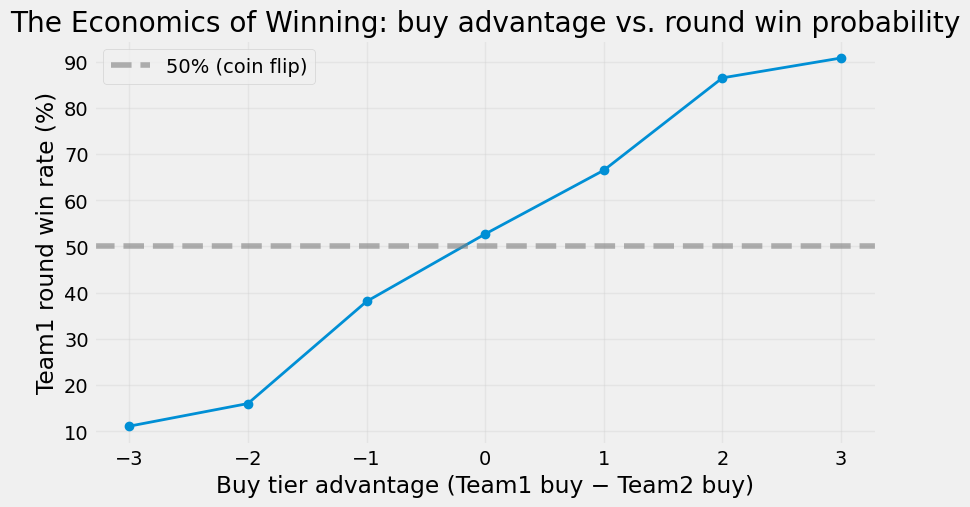

In [13]:
# Plot the win-probability curve
plt.figure(figsize=(9, 5))
plt.plot(buy_curve.index, buy_curve["win_rate"], marker="o", linewidth=2)
plt.axhline(50, color="gray", linestyle="--", alpha=0.6, label="50% (coin flip)")
plt.xlabel("Buy tier advantage (Team1 buy − Team2 buy)")
plt.ylabel("Team1 round win rate (%)")
plt.title("The Economics of Winning: buy advantage vs. round win probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Is Team1 systematically favored? Check overall Team1 win rate and odds
print("Overall Team1 round win rate:", round(rounds_df["t1_won"].mean()*100, 1), "%")

# If Team1 tends to be the favorite, that explains the tilt.
# Check whether Team1 is favored on average (Series Odds / Map Odds in the original df)
print("Team1 Map Odds > 0 share:", (df["Team1 Map Odds"] > 0).mean())
print("Mean Team1 Map Odds:", round(df["Team1 Map Odds"].mean(), 3))

Overall Team1 round win rate: 53.0 %
Team1 Map Odds > 0 share: 0.07674440211836848
Mean Team1 Map Odds: 0.152


In [15]:
# Symmetrize: view every round from BOTH teams' perspectives so the
# Team1-labeling bias cancels out.
t1_view = rounds_df[["buy_diff", "t1_won"]].rename(columns={"buy_diff": "diff", "t1_won": "won"})

t2_view = rounds_df[["buy_diff", "t1_won"]].copy()
t2_view["diff"] = -t2_view["buy_diff"]          # flip perspective
t2_view["won"]  = 1 - t2_view["t1_won"]         # T2 won if T1 didn't
t2_view = t2_view[["diff", "won"]]

symmetric = pd.concat([t1_view, t2_view])

curve = symmetric.groupby("diff")["won"].agg(win_rate="mean", rounds="count")
curve["win_rate"] = (curve["win_rate"] * 100).round(1)
print(curve)

      win_rate   rounds
diff                   
-3        10.1    17729
-2        14.6   446349
-1        35.6   646848
 0        50.0  2188122
 1        64.4   646848
 2        85.4   446349
 3        89.9    17729


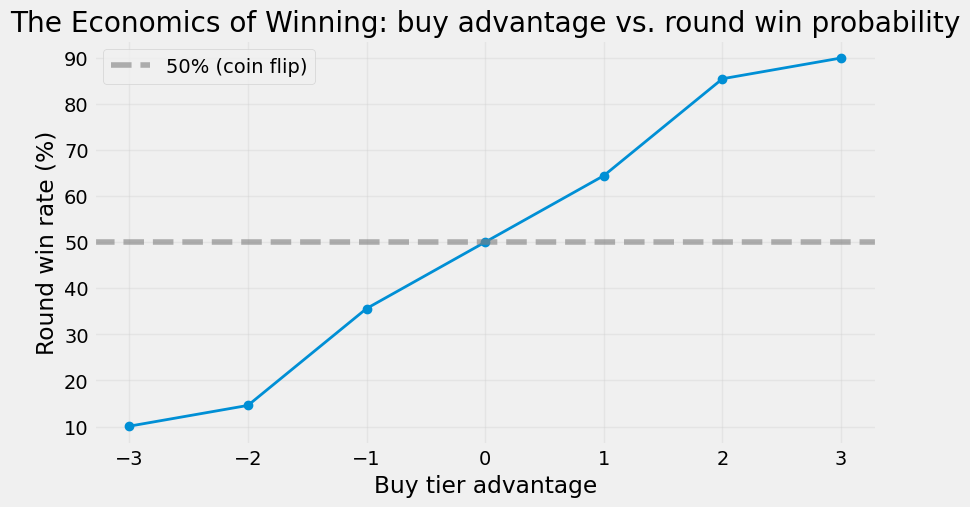

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(curve.index, curve["win_rate"], marker="o", linewidth=2)
plt.axhline(50, color="gray", linestyle="--", alpha=0.6, label="50% (coin flip)")
plt.xlabel("Buy tier advantage")
plt.ylabel("Round win rate (%)")
plt.title("The Economics of Winning: buy advantage vs. round win probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Takeaway:** After correcting for the bias, the curve is clean and symmetric. A
one-tier buy advantage yields a ~64% win rate, two tiers ~85%, and three tiers ~90%.
Economy is a powerful, quantifiable driver of round outcomes.

### Reading the buy differential: what each tier means

The x-axis, **buy differential**, is a team's own buy tier minus their opponent's,
ranging from -3 (bought far less) to +3 (bought far more). The negative side
represents economic *disadvantage*, and each step maps onto a recognizable VALORANT
situation:

- **-1 (slight disadvantage, ~36% win rate):** A light or half-buy (SMGs, light armor,
  some utility) against the opponent's full buy. Still armed and dangerous, especially
  in close-range fights, so this round is very much contestable.

- **-2 (significant disadvantage, ~15% win rate):** A force buy or partial eco (pistols,
  a cheap shotgun or Sheriff, minimal armor and utility) against a full buy. Outgunned on
  weapons, armor, and util. Winning usually requires a coordinated stack on one site or a
  favorable pistol duel.

- **-3 (near-total disadvantage, ~10% win rate):** A full eco, or "save" round, where the
  team buys almost nothing and preserves credits for the next round. The realistic goal is
  often to deal damage or snag a dropped weapon rather than to win outright. Winning is a
  genuine upset.

The positive side (+1, +2, +3) mirrors these exactly, representing the *advantaged* team.
The smooth, symmetric gradient is a good sign the analysis reflects real gameplay: the win
rates line up with how each economic state actually feels to play.

*Note: buy "tier" is a coarse bucket for amount spent, not an exact credit total, so these
are illustrative of the economic gap rather than official VALORANT buy categories.*

In [17]:
# INSIGHT A: Eco upsets — winning rounds you're "supposed" to lose
# Using the symmetric view so there's no Team1 bias.

print("ECO UPSET RATES (buying fewer tiers than your opponent)")
print("=" * 55)
for tiers in [1, 2, 3]:
    disadvantaged = symmetric[symmetric["diff"] == -tiers]
    rate = disadvantaged["won"].mean() * 100
    n = len(disadvantaged)
    print(f"  Buying {tiers} tier(s) less: won {rate:.1f}% of {n:,} rounds")

ECO UPSET RATES (buying fewer tiers than your opponent)
  Buying 1 tier(s) less: won 35.6% of 646,848 rounds
  Buying 2 tier(s) less: won 14.6% of 446,349 rounds
  Buying 3 tier(s) less: won 10.1% of 17,729 rounds


In [18]:
# Where in the map do eco upsets happen? (rounds where a team bought 2+ tiers under)
eco_rounds = rounds_df[rounds_df["buy_diff"] <= -2].copy()   # T1 on heavy eco
eco_rounds["t1_upset"] = eco_rounds["t1_won"]

upset_by_round = eco_rounds.groupby("round_num")["t1_upset"].agg(
    upset_rate="mean", n="count"
)
upset_by_round["upset_rate"] = (upset_by_round["upset_rate"] * 100).round(1)
print(upset_by_round.head(26))

           upset_rate      n
round_num                   
1               100.0      2
2                10.3  45342
3                15.1   5601
4                17.3  12978
5                19.7  15131
6                20.7   9083
7                20.0   9389
8                19.2   8212
9                18.5   8000
10               17.2   7657
11               18.6   6792
12               27.3     11
13                0.0      1
14               11.1  39503
15               14.2   5967
16               19.6   9473
17               20.3  11616
18               21.9   5817
19               21.7   4931
20               20.3   3843
21               19.6   2909
22               20.3   2107
23               22.5   1207
24               25.0      4


In [19]:
# Are eco upsets more common in "post-pistol" rounds (2 and 14)?
eco_rounds["post_pistol"] = eco_rounds["round_num"].isin([2, 14])
print("Eco-upset rate in post-pistol rounds (2, 14):",
      round(eco_rounds[eco_rounds["post_pistol"]]["t1_won"].mean()*100, 1), "%")
print("Eco-upset rate in all other rounds:          ",
      round(eco_rounds[~eco_rounds["post_pistol"]]["t1_won"].mean()*100, 1), "%")

Eco-upset rate in post-pistol rounds (2, 14): 10.7 %
Eco-upset rate in all other rounds:           19.1 %


In [20]:
# Clean comparison: post-pistol rounds vs settled rounds (drop tiny-sample pistol anomalies)
eco = rounds_df[rounds_df["buy_diff"] <= -2].copy()
eco = eco[~eco["round_num"].isin([1, 13])]   # drop pistol-round anomalies

post_pistol = eco[eco["round_num"].isin([2, 14])]
other       = eco[~eco["round_num"].isin([2, 14])]

print(f"Post-pistol eco upsets (rounds 2, 14): {post_pistol['t1_won'].mean()*100:.1f}%  (n={len(post_pistol):,})")
print(f"All other eco rounds:                  {other['t1_won'].mean()*100:.1f}%  (n={len(other):,})")
print(f"Difference: {(other['t1_won'].mean() - post_pistol['t1_won'].mean())*100:.1f} percentage points")

Post-pistol eco upsets (rounds 2, 14): 10.7%  (n=84,845)
All other eco rounds:                  19.1%  (n=130,728)
Difference: 8.4 percentage points


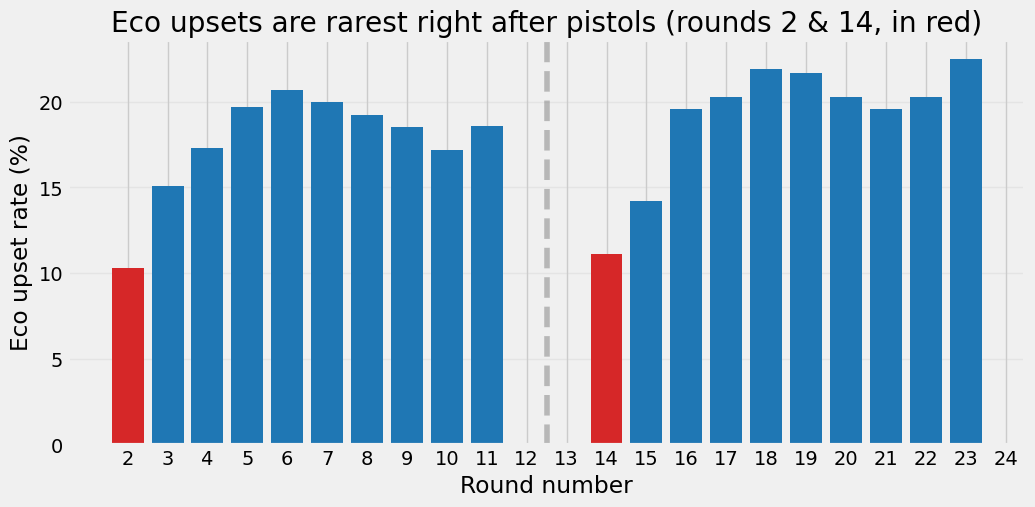

In [21]:
# Filter to well-sampled rounds only (n >= 100) so the chart is honest
plot_data = upset_by_round[upset_by_round["n"] >= 100].copy()

plt.figure(figsize=(11, 5))
colors = ["#d62728" if r in [2, 14] else "#1f77b4" for r in plot_data.index]
plt.bar(plot_data.index, plot_data["upset_rate"], color=colors)
plt.axvline(12.5, color="gray", linestyle="--", alpha=0.5)  # halftime
plt.xlabel("Round number")
plt.ylabel("Eco upset rate (%)")
plt.title("Eco upsets are rarest right after pistols (rounds 2 & 14, in red)")
plt.xticks(range(2, 25))
plt.grid(True, alpha=0.3, axis="y")
plt.show()

## Insight 2: Eco upsets and the anti-eco effect

**Question:** How often do teams win rounds where they buy 2+ tiers below their
opponent (an "eco upset"), and does the timing within the map matter?

**Finding:** Eco upsets occur ~19% of the time in settled rounds, but drop to just
**10.7%** in post-pistol rounds (2 and 14), an 8.4 percentage-point gap across ~216k
rounds. When a team wins the pistol and forces the opponent onto a broke buy, that
anti-eco converts far more reliably than a normal buy advantage later in the half.

**Rigor note:** Apparent 100% / 0% rates in rounds 1 and 13 were excluded as they came
from negligible samples (n ≤ 2); pistol rounds are buy-neutral by design.

In [22]:
# STEP 1: Compute each team's overall round win rate (strength proxy)
# Every round has a winner; credit the winning team, count appearances for both.

from collections import defaultdict
wins = defaultdict(int)
plays = defaultdict(int)

for _, r in rounds_df.iterrows():
    t1, t2 = r["Team1"], r["Team2"]
    plays[t1] += 1
    plays[t2] += 1
    if r["win_team"] == 0:
        wins[t1] += 1
    else:
        wins[t2] += 1

team_strength = {t: wins[t] / plays[t] for t in plays if plays[t] >= 500}  # min 500 rounds
print(f"Teams with 500+ rounds: {len(team_strength)}")

Teams with 500+ rounds: 1890


In [23]:
# STEP 2: Post-pistol rounds where one team has a clear buy advantage (anti-eco)
pp = rounds_df[rounds_df["round_num"].isin([2, 14])].copy()
pp = pp[pp["buy_diff"].abs() >= 2]   # one team clearly anti-ecoing

# The anti-eco team is whoever bought MORE. Did they win?
# If buy_diff > 0, Team1 is anti-ecoing; they won if t1_won==1.
# If buy_diff < 0, Team2 is anti-ecoing; they won if t1_won==0.
def anti_eco_team_and_result(row):
    if row["buy_diff"] > 0:      # Team1 anti-ecoing
        return row["Team1"], row["t1_won"]
    else:                        # Team2 anti-ecoing
        return row["Team2"], 1 - row["t1_won"]

pp[["anti_team", "anti_won"]] = pp.apply(
    lambda r: pd.Series(anti_eco_team_and_result(r)), axis=1
)
pp["anti_strength"] = pp["anti_team"].map(team_strength)
pp = pp.dropna(subset=["anti_strength"])
print(f"Post-pistol anti-eco rounds with known team strength: {len(pp):,}")

Post-pistol anti-eco rounds with known team strength: 133,516


In [24]:
# STEP 3: Anti-eco conversion rate by team strength
pp["strength_bucket"] = pd.qcut(pp["anti_strength"], 4,
                                labels=["Weakest 25%", "Lower-mid", "Upper-mid", "Strongest 25%"])
result = pp.groupby("strength_bucket", observed=True)["anti_won"].agg(
    conversion_rate="mean", n="count"
)
result["conversion_rate"] = (result["conversion_rate"] * 100).round(1)
print(result)

                 conversion_rate      n
strength_bucket                        
Weakest 25%                 89.4  33594
Lower-mid                   90.6  33365
Upper-mid                   91.7  33369
Strongest 25%               92.4  33188


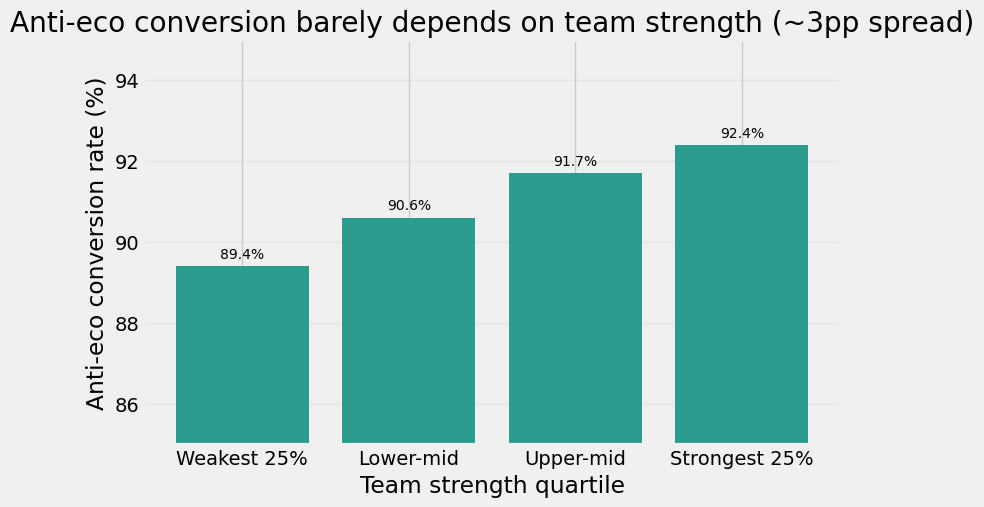

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(result.index.astype(str), result["conversion_rate"], color="#2a9d8f")
plt.ylim(85, 95)   # zoom in so the modest 3pp trend is visible but honest
plt.ylabel("Anti-eco conversion rate (%)")
plt.xlabel("Team strength quartile")
plt.title("Anti-eco conversion barely depends on team strength (~3pp spread)")
for b, v in zip(bars, result["conversion_rate"]):
    plt.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v}%", ha="center", fontsize=10)
plt.grid(True, alpha=0.3, axis="y")
plt.show()

## Insight 3: Does team strength change anti-eco success?

**Question:** Are stronger teams better at converting post-pistol anti-ecos, or is the
situation so favorable that everyone converts them?

**Finding:** Conversion rises only modestly with team strength, from 89.4% (weakest
quartile) to 92.4% (strongest), a 3pp spread across ~133k rounds. The trend is real
and perfectly ordered, but small: these rounds are won mainly by the economic and
positional advantage of the anti-eco itself, not by team skill. Even the weakest teams
convert ~89% of the time.

*(Note: the chart's y-axis starts at 85% to make the modest trend visible.)*

In [26]:
# SETUP: build a clean modeling table from the symmetric perspective
# Each round appears twice (once per team's view), so team-labeling bias cancels.
# Team1's perspective
v1 = rounds_df[["buy_diff", "bank_diff", "win_side", "t1_won", "round_num"]].copy()
v1.columns = ["buy_diff", "bank_diff", "side", "won", "round_num"]

# Team2's perspective (flip the signs and the outcome)
v2 = rounds_df[["buy_diff", "bank_diff", "win_side", "t1_won", "round_num"]].copy()
v2["buy_diff"]  = -v2["buy_diff"]
v2["bank_diff"] = -v2["bank_diff"]
v2["won"]       = 1 - v2["t1_won"]
v2["side"]      = v2["win_side"]     # side of the round winner
v2 = v2[["buy_diff", "bank_diff", "side", "won", "round_num"]]

model_df = pd.concat([v1, v2], ignore_index=True)
print(f"Modeling rows: {len(model_df):,}")
print(model_df.head())

Modeling rows: 4,409,974
   buy_diff  bank_diff  side  won  round_num
0         0        0.5     1    1          1
1         2       -8.8     1    1          2
2        -1       12.2     0    0          3
3         0       -6.6     0    0          4
4        -2      -10.8     0    0          5


## Insight 4: Modeling round wins directly

**Question:** When we account for buy advantage, bank reserves, and side simultaneously,
what actually drives winning a round?

**Method:** A logistic regression (the correct model for a binary win/loss outcome) on
the symmetric data, so there is no team-labeling bias. I model round win as a function
of buy differential, bank differential, and the winning side.

In [27]:
# LOGISTIC REGRESSION: what drives winning a round?
import statsmodels.formula.api as smf

# side: 0 = attack, 1 = defense (of the round winner) — we include it as a control
model = smf.logit("won ~ buy_diff + bank_diff + side", data=model_df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.623117
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    won   No. Observations:              4409974
Model:                          Logit   Df Residuals:                  4409970
Method:                           MLE   Df Model:                            3
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.1010
Time:                        12:46:15   Log-Likelihood:            -2.7479e+06
converged:                       True   LL-Null:                   -3.0568e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.149e-16      0.001   4.24e-13      1.000      -0.003       0.003
buy_diff       0.7588      0.

In [28]:
print("Buy diff odds ratio:", round(np.exp(0.7588), 2))
print("Bank diff odds ratio (per $1k):", round(np.exp(0.0058), 3))

Buy diff odds ratio: 2.14
Bank diff odds ratio (per $1k): 1.006


A logistic regression of round wins on economic factors (n = 4.4M symmetric observations) confirms buy advantage as the dominant economic driver: each tier of buy advantage multiplies a team's odds of winning by ~2.1 (β = 0.76, p < 0.001). Bank reserves have a positive but marginal effect after controlling for current buy (β = 0.006 per $1k, OR ≈ 1.006), indicating that what you spend this round matters far more than what you have saved. The near-zero intercept confirms the symmetrized model is unbiased (even matchups = 50%), and side drops out by construction. With a pseudo-R² of 0.10, economy meaningfully shapes round outcomes while leaving most variance to skill and execution — as expected.

In [29]:
# ECO UPSETS BY MAP: which maps see the most "buying less but winning anyway"?
# Using the symmetric idea: for each map code, what % of heavy-eco rounds get won?

# First, attach map code to each round (rounds_df already has "Map" from the parent map)
eco = rounds_df[rounds_df["buy_diff"] <= -2].copy()   # heavy eco situations
eco["upset"] = eco["t1_won"]

map_upsets = eco.groupby("Map")["upset"].agg(
    upset_rate="mean", eco_rounds="count"
)
map_upsets["upset_rate"] = (map_upsets["upset_rate"] * 100).round(1)

# Only keep real maps with enough data (drop -1/0 placeholders and thin samples)
map_upsets = map_upsets[(map_upsets.index > 0) & (map_upsets["eco_rounds"] >= 1000)]
map_upsets = map_upsets.sort_values("upset_rate", ascending=False)
print(map_upsets)

     upset_rate  eco_rounds
Map                        
10         17.4        6057
6          16.8       14812
9          16.7       14595
8          16.2        8064
3          15.8       38076
1          15.6       47190
2          15.5       27376
7          15.4       10491
4          15.3       20450
5          15.1       28118


### A quick check: does the map matter?

Eco-upset rates vary only slightly across the 11 map codes (15.1% to 17.4%, a
2.3-point range). Compared to the 8.4-point swing driven by round *timing*
(post-pistol vs. settled rounds), this suggests map geometry plays a minor role in
eco success relative to economic and situational factors. Maps are left as numeric
codes here, as decoding them would not change this conclusion.

In [30]:
pd.set_option("display.max_colwidth", None)
print(df[df["Map"] == 1]["VOD Link"].iloc[0]) # Map 1 is Ascent
print(df[df["Map"] == 2]["VOD Link"].iloc[0]) # Map 2 is Bind
print(df[df["Map"] == 3]["VOD Link"].iloc[0]) # Map 3 is Haven
print(df[df["Map"] == 4]["VOD Link"].iloc[0]) # Map 4 is Split
print(df[df["Map"] == 5]["VOD Link"].iloc[0]) # Map 5 is Icebox
print(df[df["Map"] == 6]["VOD Link"].iloc[0]) # Map 6 is Breeze
print(df[df["Map"] == 7]["VOD Link"].iloc[0]) # Map 7 is Fracture
print(df[df["Map"] == 8]["VOD Link"].iloc[0]) # Map 8 is Pearl
print(df[df["Map"] == 9]["VOD Link"].iloc[0]) # Map 9 is Lotus
print(df[df["Map"] == 10]["VOD Link"].iloc[0]) # Map 10 is Sunset
df.head(1) # Map 11 is Abyss (too small of a sample size)

https://youtu.be/NmoNwQvqT0U?t=436
https://youtu.be/CUt9cHF23uE?list=PLTlFZO3kdyGA8GkKp_UYMF8hcVWyMT0T0&t=537
https://youtu.be/ljYModJBqFU?t=470
https://youtu.be/f2CPJmqbRWc?t=10138
https://youtu.be/dSIZTqcvr-g?list=PLTlFZO3kdyGA8GkKp_UYMF8hcVWyMT0T0&t=520
https://youtu.be/EmC3rS5CUD8?t=5928
https://youtu.be/Mz1zvTyRK1g?t=1723
https://youtu.be/Mz1zvTyRK1g?t=5373
https://youtu.be/W_7Oq_L7iv8?t=384
https://youtu.be/Li-sxK6NEhI?list=PLTlFZO3kdyGA8GkKp_UYMF8hcVWyMT0T0&t=291


,MatchID,GameID,EventID,Date,Team1ID,Team2ID,Team1 Name,Team2 Name,Series Odds,Team1 Map Odds,Map,Team1 Rounds,Team2 Rounds,Team1 Atk Rounds,Team2 Atk Rounds,Team1 Def Rounds,Team2 Def Rounds,Team1 Rating,Team2 Rating,Team1 ACS,Team2 ACS,Team1 Kills,Team2 Kills,Team1 Deaths,Team2 Deaths,Team1 Assists,Team2 Assists,Team1 DeltaK/D,Team2 DeltaK/D,Team1 KAST,Team2 KAST,Team1 ADR,Team2 ADR,Team1 HS,Team2 HS,Team1 FK,Team2 FK,Team1 FD,Team2 FD,Team1 DeltaFK/FD,Team2 DeltaFK/FD,Team1 Pistols,Team2 Pistols,Team1 EcosWon,Team2 EcosWon,Team1 Ecos,Team2 Ecos,Team1 Semibuys Won,Team2 Semibuys Won,Team1 Semibuys,Team2 Semibuys,Team1 Fullbuys Won,Team2 Fullbuys Won,Team1 Fullbuys,Team2 Fullbuys,Round Breakdown,Team1Game1,Team1Game2,Team1Game3,Team1Game4,Team1Game5,Team2Game1,Team2Game2,Team2Game3,Team2Game4,Team2Game5,VOD Link
0,381258,180991,2158,2024-09-04,15139,15138,MYVRA,KS Hunters,0.0,0.0,11,13,9,7.0,6.0,6.0,3.0,1.134,0.87,211.4,178.2,83.0,70.0,70.0,83.0,39.0,32.0,13.0,-13.0,72.8,66.6,134.8,115.8,29.4,29.8,12.0,10.0,10.0,12.0,2.0,-2.0,2.0,0.0,0.0,0.0,2.0,3.0,4.0,2.0,7.0,4.0,7.0,7.0,11.0,13.0,0100!0.6!0.1!0120!0.9!9.7!1023!13.3!1.1!1033!2.6!9.2!1013!7.9!18.7!0133!2.5!27.5!0123!3.8!15.2!1033!10.8!5.6!1023!3.4!5.6!0123!9.7!12.9!0132!13.2!6.2!1032!18.0!1.4!0000!0.2!0.3!0020!3.2!9.0!1123!13.0!1.0!1132!4.5!4.6!1113!8.1!6.8!0033!2.9!15.9!0033!15.8!4.2!0031!14.8!9.5!0033!22.9!2.1!0032!26.4!2.6!,381254,381252,381247,381242,365378,381253,381251,381249,381243,365377,https://youtu.be/-iaPdT6K73o?t=974


In [31]:
# The decoded map lookup
map_names = {
    1: "Ascent",
    2: "Bind",
    3: "Haven",
    4: "Split",
    5: "Icebox",
    6: "Breeze",
    7: "Fracture",
    8: "Pearl",
    9: "Lotus",
    10: "Sunset",
    11: "Abyss",
}

# Apply to both dataframes
df["map_name"] = df["Map"].map(map_names)
rounds_df["map_name"] = rounds_df["Map"].map(map_names)

# Codes 0 and -1 will become NaN (they're the missing-data placeholders) — that's correct
print(rounds_df["map_name"].value_counts(dropna=False))

map_name
Ascent      470675
Haven       394318
Icebox      288558
Bind        285019
Split       205662
Lotus       156346
Breeze      150765
Fracture    106428
Pearl        80787
Sunset       62495
Abyss         3629
NaN            305
Name: count, dtype: int64


In [32]:
# Eco upsets by map — now with names
eco = rounds_df[rounds_df["buy_diff"] <= -2].copy()
eco["upset"] = eco["t1_won"]

map_upsets = eco.groupby("map_name")["upset"].agg(upset_rate="mean", eco_rounds="count")
map_upsets["upset_rate"] = (map_upsets["upset_rate"] * 100).round(1)
map_upsets = map_upsets[map_upsets["eco_rounds"] >= 1000].sort_values("upset_rate", ascending=False)
print(map_upsets)

          upset_rate  eco_rounds
map_name                        
Sunset          17.4        6057
Breeze          16.8       14812
Lotus           16.7       14595
Pearl           16.2        8064
Haven           15.8       38076
Ascent          15.6       47190
Bind            15.5       27376
Fracture        15.4       10491
Split           15.3       20450
Icebox          15.1       28118


### A quick check: does the map matter?

VALORANT theory suggests eco upsets should cluster on tighter, more close-quarters
maps, where cheap weapons (SMGs, shotguns) stay viable, and be rarer on open maps
where you need rifles to hold long angles. Does the data agree?

**Decoding the maps:** The dataset stores maps as numeric codes with no lookup table,
so I identified each one by opening a sample VOD per code and confirming the map being
played. This produced the full mapping (1 = Ascent, 2 = Bind, 3 = Haven, 4 = Split,
5 = Icebox, 6 = Breeze, 7 = Fracture, 8 = Pearl, 9 = Lotus, 10 = Sunset, 11 = Abyss).

**Finding:** Eco-upset rate varies only slightly across maps, from 15.1% (Icebox) to
17.4% (Sunset), a 2.3-point range. The small variation that exists runs in the expected
direction: tighter maps like Sunset sit at the top, while more open maps like Icebox sit
at the bottom. But compared to the 8.4-point swing driven by round *timing*
(post-pistol vs. settled rounds), map geometry is a minor factor.

**Takeaway:** Economy and situational timing dominate eco-upset success; the specific
map plays only a small, secondary role, consistent in direction with the game's design
but modest in magnitude. (Abyss is excluded from the ranking due to a small sample,
n = 179 maps.)

## Conclusion

Across ~2.8M rounds, economy emerges as a real but bounded driver of round outcomes:
buy advantage roughly doubles win odds per tier, yet the model explains ~10% of the
variance, leaving the rest to aim, positioning, and execution. The most actionable
insight: anti-ecos are among the most reliable situations in the game, and are largely
skill-independent.

**Limitations:** This is professional (VCT) data, so findings describe high-level play
and may not generalize to ranked ladder play. Buy "tier" is a coarse proxy for exact
credits spent. Map identifiers were left as numeric codes and not decoded in this
analysis.

*Analysis by Yusri Souissi · Python, pandas, statsmodels*

*Dataset provided by u/benetheburrito on r/ValorantCompetitive and scraped from u.gg*

In [33]:
# EXPORT SUMMARY TABLES FOR TABLEAU

# 1. Buy-advantage win curve (your hero chart) — from the symmetric data
buy_curve_export = symmetric.groupby("diff")["won"].agg(win_rate="mean", rounds="count").reset_index()
buy_curve_export["win_rate"] = (buy_curve_export["win_rate"] * 100).round(1)
buy_curve_export.to_csv("tableau_buy_curve.csv", index=False)

# 2. Eco upsets by round number (the post-pistol dip chart)
eco = rounds_df[rounds_df["buy_diff"] <= -2].copy()
eco["upset"] = eco["t1_won"]
eco_by_round = eco.groupby("round_num")["upset"].agg(upset_rate="mean", n="count").reset_index()
eco_by_round["upset_rate"] = (eco_by_round["upset_rate"] * 100).round(1)
eco_by_round = eco_by_round[eco_by_round["n"] >= 100]   # drop tiny samples
eco_by_round["is_post_pistol"] = eco_by_round["round_num"].isin([2, 14])
eco_by_round.to_csv("tableau_eco_by_round.csv", index=False)

# 3. Eco upsets by map (the map check)
eco_by_map = eco.groupby("map_name")["upset"].agg(upset_rate="mean", n="count").reset_index()
eco_by_map["upset_rate"] = (eco_by_map["upset_rate"] * 100).round(1)
eco_by_map = eco_by_map[eco_by_map["n"] >= 1000].sort_values("upset_rate", ascending=False)
eco_by_map.to_csv("tableau_eco_by_map.csv", index=False)

# 4. Anti-eco conversion by team strength
result_export = result.reset_index()
result_export.to_csv("tableau_antieco_strength.csv", index=False)

print("Exported 4 CSVs for Tableau:")
print("  tableau_buy_curve.csv")
print("  tableau_eco_by_round.csv")
print("  tableau_eco_by_map.csv")
print("  tableau_antieco_strength.csv")

Exported 4 CSVs for Tableau:
  tableau_buy_curve.csv
  tableau_eco_by_round.csv
  tableau_eco_by_map.csv
  tableau_antieco_strength.csv


In [34]:
import sqlite3

# Create an in-memory SQLite database and load the round-level data into it
conn = sqlite3.connect(":memory:")
rounds_df.to_sql("rounds", conn, index=False, if_exists="replace")

# Quick test that it loaded
pd.read_sql("SELECT COUNT(*) AS total_rounds FROM rounds", conn)

,total_rounds
0,2204987
